# **XGB-DQN**

# S0 Preparation
### **S0** 准备工作

Before running the code, make sure to perform the following preparation steps.
- [x] Install Anaconda
- [x] Create a new environment
- [x] Install the following Python packages in the new environment: numpy, pandas, tensorflow, xgboost, scikit-learn, scikit-optimize, ...
- [x] Run Jupyter Lab in the new environment
- [x] Navigate to this file by double-clicking on it in the file directory on the left side of Jupyter Lab 
- [x] Choose the kernel of the new environment in the top right corner of Jupyter Lab

在运行代码前，请确保完成以下准备工作：
- [x] 安装Anaconda
- [x] 创建一个新的环境
- [x] 在新环境安装以下python包：numpy, pandas, tensorflow, xgboost, scikit-learn, scikit-optimize ...
- [x] 在新环境下运行jupyter lab
- [x] 在jupyter左侧的文件夹目录下找到本文件并双击打开
- [x] 在jupyter右上角选择新环境的kernel

## **S1** Importing Python Packages
### **S1** 导入所有的python包

In [11]:
#导入常用的库
import pandas as pd 
import numpy as np
from numpy import loadtxt
import random
import tensorflow as tf
import xgboost as xgb # 1.5.0
from skopt import BayesSearchCV 
from skopt.space import Integer
from collections import deque
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error 
from sklearn import metrics
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import BayesianRidge
from sklearn import ensemble
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted

import warnings
warnings.filterwarnings("ignore")


def ensure_numeric_features(df):
    """Label-encode non-numeric columns in place (object / Pandas 2 str dtype)."""
    for col in df.columns:
        s = df[col]
        if pd.api.types.is_datetime64_any_dtype(s):
            continue
        if pd.api.types.is_numeric_dtype(s) or pd.api.types.is_bool_dtype(s):
            continue
        lb = LabelEncoder()
        df[col] = lb.fit_transform(s.astype(str))

## **S2** Training the XGBoost Model
### **S2** 训练XGBoost模型

In [12]:
# 1. Read the processed CSV file, modify the file paths based on your actual file locations
# 1.读取处理后的csv文件，根据您的文件保存路径进行修改
from pathlib import Path

# Robust dataset discovery:
# - If you launch Jupyter from a different directory, Path.cwd() may not be the project root.
# - We try a few parent directories to find the CSVs.

def _find_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for base in candidates[:6]:
        if (base / "Cleaned_data.csv").is_file() and (base / "Cleaned_data_encode.csv").is_file():
            return base
    raise FileNotFoundError(
        "Không tìm thấy Cleaned_data.csv / Cleaned_data_encode.csv. "
        "Hãy chạy notebook từ thư mục project hoặc đặt DATA_DIR thủ công."
    )

DATA_DIR = _find_data_dir()
xgb_file = DATA_DIR / "Cleaned_data.csv"
xgb_encode_file = DATA_DIR / "Cleaned_data_encode.csv"
print("[DATA_DIR]", DATA_DIR)

# 2. Read the data 3. Set the timestamp format # 4. Remove missing values
# 2. 读取数据  3. 设定时间戳格式  4. 删除缺失值
data = pd.read_csv(xgb_file, encoding="utf-8")
data["Date_Time"] = pd.to_datetime(data["Date_Time"], errors="coerce")
data = data.dropna(subset=["Date_Time"]).dropna()
data = data[data != -999].dropna()
# data.head()

[DATA_DIR] /home/dat/Desktop/Hvac-Window-based-XGB-DQN


In [13]:
# 5. Encode non-numeric variables
# 5. 将非数值类型的变量进行编码
ensure_numeric_features(data)
data.head()

# data.to_csv(xgb_encode_file,index=False)  

,ID,Date_Time,AC_Status,Window_Status,CLast_Time,CLast_Time_T,WLast_Time,WLast_Time_T,Indoor_Temp,Indoor_RH,...,Room_ID,Study_ID,City,Next_Indoor_Temp,Next_Indoor_RH,Next_Outdoor_Temp,Next_Outdoor_RH,Differ_Outdoor_Temp,Differ_Indoor_Temp,Target_Temp
0,1,2019-03-05 00:00:00,0,0.0,0,0,0.0,0.0,25.12,70.84,...,0,6,0,25.09,71.22,26.0,84.0,0.0,-0.03,0.0
1,2,2019-03-05 01:00:00,0,0.0,0,0,0.0,0.0,25.09,71.22,...,0,6,0,25.05,71.66,26.0,89.0,0.0,-0.04,0.0
2,3,2019-03-05 02:00:00,0,0.0,0,0,0.0,0.0,25.05,71.66,...,0,6,0,25.02,71.84,26.0,89.0,0.0,-0.03,0.0
3,4,2019-03-05 03:00:00,0,0.0,0,0,0.0,0.0,25.02,71.84,...,0,6,0,24.97,72.11,25.0,89.0,-1.0,-0.05,0.0
4,5,2019-03-05 04:00:00,0,0.0,0,0,0.0,0.0,24.97,72.11,...,0,6,0,24.92,72.12,25.0,89.0,0.0,-0.05,0.0


In [14]:
# 6. Check information about the 'data' DataFrame
# 6. 检查data的信息
data.info()

<class 'pandas.DataFrame'>
Index: 42338 entries, 0 to 42932
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   42338 non-null  int64         
 1   Date_Time            42338 non-null  datetime64[us]
 2   AC_Status            42338 non-null  int64         
 3   Window_Status        42338 non-null  float64       
 4   CLast_Time           42338 non-null  int64         
 5   CLast_Time_T         42338 non-null  int64         
 6   WLast_Time           42338 non-null  float64       
 7   WLast_Time_T         42338 non-null  float64       
 8   Indoor_Temp          42338 non-null  float64       
 9   Indoor_RH            42338 non-null  float64       
 10  Outdoor_Temp         42338 non-null  int64         
 11  Outdoor_RH           42338 non-null  int64         
 12  Rain                 42338 non-null  int64         
 13  Cloud                42338 non-null  int64     

In [15]:
# 7. 'x' represents independent variables, 'y' represents the feature to be predicted
# 7. x是自变量，y是要被预测的特征
ensure_numeric_features(data)

x = data.drop(['Next_Indoor_Temp','Next_Indoor_RH','Date_Time','Study_ID','Differ_Indoor_Temp','ID'],axis=1)
y = data['Differ_Indoor_Temp']

# 8. Split the dataset into training and testing sets
# 8. 划分训练集和测试集
x_train, x_test, y_train, y_test = train_test_split(x, 
                                                    y,
                                                    test_size=0.2,
                                                    random_state=2022)

In [16]:
# 8. Bayesian Hyperparameter Tuning, Print the Best Parameters
# 8. 贝叶斯调参，打印最优参数
opt = BayesSearchCV(xgb.XGBRegressor(verbosity=0,
                              n_jobs=-1,
                                random_state=2022), 
                    { 
                    'max_depth': Integer(3, 5), 
                    'n_estimators': Integer(100, 500), 
                    'learning_rate': (0.1, 0.5)},
                    random_state=2022,
                    scoring='r2',
                    n_iter=20,
                    cv=3)
opt.fit(x_train, y_train)
model_XGB = opt.best_estimator_
print(f'best params: {opt.best_params_}')

best params: OrderedDict({'learning_rate': 0.16172008875388022, 'max_depth': 5, 'n_estimators': 428})


In [17]:
# 9. Use the Best Parameters from Bayesian Hyperparameter Tuning and Train the Model
# 9. 根据贝叶斯调参的最优参数进行修改，然后开始训练
model_XGB = xgb.XGBRegressor(random_state=2000,
                            verbosity=1,
                             n_jobs=-1,
                             max_depth=5, 
                            learning_rate=0.23474, 
                            n_estimators=500)
model_XGB.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

## **S3** 定义DQN的框架

In [18]:
# Create Experience Replay Buffer
# 创建经验回放缓冲区
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, state, action, next_state, reward):
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = (state, action, next_state, reward)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

# 创建DQN模型
class DQN(tf.keras.Model):
    def __init__(self):
        super(DQN, self).__init__()
        self.dense1 = tf.keras.layers.Dense(64, activation='relu')
        self.dense2 = tf.keras.layers.Dense(64, activation='relu')
        self.output_layer = tf.keras.layers.Dense(num_actions, activation='linear')

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.output_layer(x)
        
# Create Deep Q-Network (DQN) Model
# 创建Q网络更新函数
def update_Q_network():
    states, actions, next_states, rewards = zip(*replay_buffer.sample(batch_size))
    states = np.array(states)
    actions = np.array(actions)
    next_states = np.array(next_states)
    rewards = np.array(rewards)

    with tf.GradientTape() as tape:
        Q_values = Q_network(states)
        target_Q_values = Q_network(next_states)
        target_Q_values = rewards + gamma * tf.reduce_max(target_Q_values, axis=1)
        mask = tf.one_hot(actions, num_actions)
        Q_action = tf.reduce_sum(tf.multiply(Q_values, mask), axis=1)
        loss = loss_function(target_Q_values, Q_action)

    grads = tape.gradient(loss, Q_network.trainable_variables)
    optimizer.apply_gradients(zip(grads, Q_network.trainable_variables))

# Create Target Network Update Function
# 创建目标网络更新函数
def update_target_network():
    target_network.set_weights(Q_network.get_weights())

# Create ε-Greedy Policy
# 创建ε-greedy策略
def epsilon_greedy_policy(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(num_actions)
    else:
        Q_values = Q_network(np.array([state]))
        return np.argmax(Q_values)
        
# Define Reward Function
# 定义奖励函数
def calculate_reward(state, step, action, next_state):
    reward = 0
    standard = 'ASHRAE'
    coordinates_dict = {'ASHRAE': [[17.4, 18.4, 23.4, 24.4], [23.6, 24.6, 29.6, 30.6], [10, 30]]}
    L11, L12, U12, U11 = coordinates_dict[standard][0]
    L21, L22, U22, U21 = coordinates_dict[standard][1]
    T1, T2 = coordinates_dict[standard][2]
    InT, OutT = next_state[0], next_state[2]
    if OutT <= T1:
        L1, L2, U2, U1 = L11, L12, U12, U11
    elif OutT >= T2:
        L1, L2, U2, U1 = L21, L22, U22, U21
    else:
        increase = (OutT-T1)*(L21-L11)/(T2-T1)
        L1, L2, U2, U1 = L11+increase, L12+increase, U12+increase, U11+increase
    if InT>=L2 and InT<=U2:
        reward = 0
    elif InT<L2:
        reward = -(InT-L2) ** 2
    elif InT>U2:
        reward = -(InT-U2) ** 2
    if action==0 or action==12:
        reward = reward+0
    elif action>12:
        reward = reward-2*(60*0.87*1)
    else:
        reward = reward-(60*0.87*1)
    return reward
    
# Establish Mapping between Actions and Index
# 建立action和索引的映射关系
def map_action_to_dataframe(action):
    Target_Temp, AC_Status, Window_Status,CLast_Time,WLast_Time = 0,0,0,0,0
    action = int(action)
    if action == 0:
        Target_Temp = 0
        AC_Status = 0
        CLast_Time = 0
        Window_Status = 0
        WLast_Time = 0
    elif action>0 and action<12:
        Target_Temp = 19 + action
        AC_Status = 1
        CLast_Time = 60
        Window_Status = 0
        WLast_Time = 0
    elif action == 12:
        Target_Temp = 0
        AC_Status = 0
        CLast_Time = 0
        Window_Status = 1
        WLast_Time = 60
    else:
        Target_Temp = action+7
        AC_Status = 1
        CLast_Time = 60
        Window_Status = 1
        WLast_Time = 60
    return Target_Temp, AC_Status, Window_Status,CLast_Time,WLast_Time

In [19]:
# Filter Data for One Day
# 筛选出一天的数据样本
def chose_data(a,data):
    data_test00 = data[a:a+23]
    data_test0a = data_test00.reset_index(drop=True) # 备份
    data_test0 = data_test00.reset_index(drop=True)
    new_time_c = data_test0a.iloc[0]['CLast_Time_T'] - data_test0a.iloc[0]['AC_Status']*60
    data_test0.at[0,'CLast_Time_T'] = new_time_c
    new_time_w = data_test0a.iloc[0]['WLast_Time_T'] - data_test0a.iloc[0]['Window_Status']*60
    data_test0.at[0,'WLast_Time_T'] = new_time_w
    data_test = data_test0[['Indoor_Temp','Indoor_RH','Outdoor_Temp','Outdoor_RH','Rain','Cloud','Windspeed','Hour','Next_Outdoor_Temp','Next_Outdoor_RH']].copy()
    xgboost_test = data_test0.drop(['Next_Indoor_Temp','Next_Indoor_RH','Date_Time','Study_ID','Differ_Indoor_Temp','ID'],axis=1)
    return data_test,xgboost_test

## **S4** 将XGB和DQN集成并进行训练

In [20]:
episode_list = []
total_reward_list = []
best_policy = []
next_in_temp_list = []
AC_Status_List=[]
W_Status_List=[]

ensure_numeric_features(data)
_drop_x = ['Next_Indoor_Temp', 'Next_Indoor_RH', 'Date_Time', 'Study_ID', 'Differ_Indoor_Temp', 'ID']
if 'x_train' not in globals() or 'y_train' not in globals():
    x = data.drop(_drop_x, axis=1)
    y = data['Differ_Indoor_Temp']
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2022)
elif any(
    not (pd.api.types.is_numeric_dtype(x_train[c]) or pd.api.types.is_bool_dtype(x_train[c]))
    for c in x_train.columns
):
    x = data.drop(_drop_x, axis=1)
    y = data['Differ_Indoor_Temp']
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2022)

if 'model_XGB' not in globals():
    if 'opt' in globals() and getattr(opt, 'best_estimator_', None) is not None:
        model_XGB = opt.best_estimator_
    else:
        model_XGB = xgb.XGBRegressor(
            random_state=2000,
            verbosity=0,
            n_jobs=-1,
            max_depth=5,
            learning_rate=0.23474,
            n_estimators=500,
        )

try:
    check_is_fitted(model_XGB)
except NotFittedError:
    model_XGB.fit(x_train, y_train)

data_RL = data

for i in range(0,1):
    # Define Parameters
    # 定义参数
    num_features = 8
    num_actions = 24
    gamma = 0.9  # Discount factor 折扣因子
    epsilon = 1.0  # Initial exploration rate 初始探索率
    min_epsilon = 0.1  # Minimum exploration rate 最小探索率
    epsilon_decay = 0.995  # Exploration rate decay factor 探索率衰减因子，ε-greedy策略中的ε
    learning_rate = 0.001  # Learning rate 学习率，通常选择0.001有利于收敛
    memory_capacity = 10000  # Experience replay buffer capacity 经验回放缓冲区容量
    batch_size = 32  # Batch size 批量处理大小

    # Create Q-Network and Target Network
    # 创建Q网络和目标网络
    Q_network = DQN()
    target_network = DQN()
    
    # Define Loss Function and Optimizer
    # 定义损失函数和优化器
    loss_function = tf.losses.MeanSquaredError()
    optimizer = tf.optimizers.Adam(learning_rate)
    
    # Create Experience Replay Buffer
    # 创建经验回放缓冲区
    replay_buffer = ReplayBuffer(memory_capacity)

    # Train DQN
    # 训练 DQN
    data_test,xgboost_test = chose_data(i*24,data_RL)
    num_episodes = 1000
    for episode in range(num_episodes):
        episode_list.append(episode)
        data_pre_test = data_test
        xgboost_pre_test = xgboost_test
        total_reward = 0
        for step in range(6):
            xgboost_pre_test.loc[step, ['Target_Temp', 'AC_Status', 'Window_Status', 'CLast_Time', 'WLast_Time', 'CLast_Time_T', 'WLast_Time_T']] = 0
            hour_row_df = pd.DataFrame(xgboost_pre_test.iloc[step]).T
            next_differ_temp_list = model_XGB.predict(hour_row_df) 
            next_differ_temp = next_differ_temp_list[0]
            next_in_temp = xgboost_pre_test.iloc[step]['Indoor_Temp']+next_differ_temp
            xgboost_pre_test.at[step+1,'Indoor_Temp'] = next_in_temp
            data_pre_test.at[step+1,'Indoor_Temp'] = next_in_temp
        state = data_pre_test.iloc[6, :num_features].values  # 开始工作的初始始状态   
        for step in range(6,18):
            action = epsilon_greedy_policy(state, epsilon)
            Target_Temp, AC_Status, Window_Status,CLast_Time,WLast_Time = map_action_to_dataframe(action)
            xgboost_pre_test.at[step,'Target_Temp'] = Target_Temp
            xgboost_pre_test.at[step,'AC_Status'] = AC_Status
            xgboost_pre_test.at[step,'Window_Status'] = Window_Status
            xgboost_pre_test.at[step,'CLast_Time'] = CLast_Time
            xgboost_pre_test.at[step,'WLast_Time'] = WLast_Time
            if CLast_Time > 0:
                xgboost_pre_test.at[step, 'CLast_Time_T'] = xgboost_pre_test.iloc[step-1]['CLast_Time_T'] + CLast_Time
            else:
                xgboost_pre_test.at[step, 'CLast_Time_T'] = 0
            if WLast_Time > 0:
                xgboost_pre_test.at[step, 'WLast_Time_T'] = xgboost_pre_test.iloc[step-1]['WLast_Time_T'] + WLast_Time
            else:
                xgboost_pre_test.at[step, 'WLast_Time_T'] = 0
            hour_row_df = pd.DataFrame(xgboost_pre_test.iloc[step]).T
            next_differ_temp_list = model_XGB.predict(hour_row_df) 
            next_differ_temp = next_differ_temp_list[0]
            next_in_temp = xgboost_pre_test.iloc[step]['Indoor_Temp']+next_differ_temp
            xgboost_pre_test.at[step+1,'Indoor_Temp'] = next_in_temp
            data_pre_test.at[step+1,'Indoor_Temp'] = next_in_temp
            next_state = data_pre_test.iloc[step+1, :num_features].values           
            reward = calculate_reward(state,step, action, next_state)
            total_reward += reward
            replay_buffer.push(state, action, next_state, reward)
            state = next_state
            if epsilon > min_epsilon:
                    epsilon *= epsilon_decay
            if len(replay_buffer.memory) >= batch_size:
                update_Q_network()
        total_reward_list.append(total_reward)
        
    # Training Completed, Make Decisions    
    # 训练完成，进行决策
    data_pre_test = data_test
    xgboost_pre_test = xgboost_test
    for step in range(0,6):
        if step ==0:
            temp_original = data_pre_test.iloc[step]['Indoor_Temp']
            next_in_temp_list.append(temp_original)
        best_policy.append(0)
        AC_Status_List.append(0)
        W_Status_List.append(0)
        xgboost_pre_test.loc[step, ['Target_Temp', 'AC_Status', 'Window_Status', 'CLast_Time', 'WLast_Time', 'CLast_Time_T', 'WLast_Time_T']] = 0
        hour_row_df = pd.DataFrame(xgboost_pre_test.iloc[step]).T
        next_differ_temp_list = model_XGB.predict(hour_row_df) 
        next_differ_temp = next_differ_temp_list[0]
        next_in_temp = xgboost_pre_test.iloc[step]['Indoor_Temp']+next_differ_temp
        xgboost_pre_test.at[step+1,'Indoor_Temp'] = next_in_temp
        next_in_temp_list.append(next_in_temp)
        data_pre_test.at[step+1,'Indoor_Temp'] = next_in_temp
    state = data_pre_test.iloc[6, :num_features].values
    for step in range(6,18):
        action = epsilon_greedy_policy(state, 0)
        Target_Temp, AC_Status, Window_Status,CLast_Time,WLast_Time = map_action_to_dataframe(action)
        best_policy.append(action)
        AC_Status_List.append(AC_Status)
        W_Status_List.append(Window_Status)
        xgboost_pre_test.at[step,'Target_Temp'] = Target_Temp
        xgboost_pre_test.at[step,'AC_Status'] = AC_Status
        xgboost_pre_test.at[step,'Window_Status'] = Window_Status
        xgboost_pre_test.at[step,'CLast_Time'] = CLast_Time
        xgboost_pre_test.at[step,'WLast_Time'] = WLast_Time
        if CLast_Time > 0:
            xgboost_pre_test.at[step, 'CLast_Time_T'] = xgboost_pre_test.iloc[step-1]['CLast_Time_T'] + CLast_Time
        else:
            xgboost_pre_test.at[step, 'CLast_Time_T'] = 0
        if WLast_Time > 0:
            xgboost_pre_test.at[step, 'WLast_Time_T'] = xgboost_pre_test.iloc[step-1]['WLast_Time_T'] + WLast_Time
        else:
            xgboost_pre_test.at[step, 'WLast_Time_T'] = 0
        hour_row_df = pd.DataFrame(xgboost_pre_test.iloc[step]).T
        next_differ_temp_list = model_XGB.predict(hour_row_df) 
        next_differ_temp = next_differ_temp_list[0]
        next_in_temp = xgboost_pre_test.iloc[step]['Indoor_Temp']+next_differ_temp
        xgboost_pre_test.at[step+1,'Indoor_Temp'] = next_in_temp
        next_in_temp_list.append(next_in_temp)
        data_pre_test.at[step+1,'Indoor_Temp'] = next_in_temp
        next_state = data_pre_test.iloc[step+1, :num_features].values      
        state = next_state
    for step in range(18,23):
        best_policy.append(0)
        AC_Status_List.append(0)
        W_Status_List.append(0)
        xgboost_pre_test.loc[step, ['Target_Temp', 'AC_Status', 'Window_Status', 'CLast_Time', 'WLast_Time', 'CLast_Time_T', 'WLast_Time_T']] = 0
        hour_row_df = pd.DataFrame(xgboost_pre_test.iloc[step]).T
        next_differ_temp_list = model_XGB.predict(hour_row_df) 
        next_differ_temp = next_differ_temp_list[0]
        next_in_temp = xgboost_pre_test.iloc[step]['Indoor_Temp']+next_differ_temp
        xgboost_pre_test.at[step+1,'Indoor_Temp'] = next_in_temp
        next_in_temp_list.append(next_in_temp)
        data_pre_test.at[step+1,'Indoor_Temp'] = next_in_temp
    best_policy.append(0)  
    AC_Status_List.append(0)
    W_Status_List.append(0)  
    
    print(best_policy[(i)*24:(i+1)*24])
    print(next_in_temp_list[(i)*24:(i+1)*24])

[0, 0, 0, 0, 0, 0, np.int64(0), np.int64(12), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), 0, 0, 0, 0, 0, 0]
[np.float64(25.12), np.float64(25.032279903888703), np.float64(24.996304473727943), np.float64(25.087968832701446), np.float64(25.05117031082511), np.float64(25.07932515151799), np.float64(25.112416759952904), np.float64(25.139607421010734), np.float64(25.22213079676032), np.float64(25.25684478029609), np.float64(25.35284650221467), np.float64(25.51017388597131), np.float64(25.93164724007249), np.float64(26.314467131048442), np.float64(26.614562301784755), np.float64(27.022970734983684), np.float64(27.310690133720637), np.float64(27.605815826803447), np.float64(27.730242616385222), np.float64(27.4151508872211), np.float64(27.414655921694358), np.float64(27.45899666258367), np.float64(27.63162829884561), np.float64(27.78536426433595)]


## **S5** Visualization
### **S5** 可视化

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

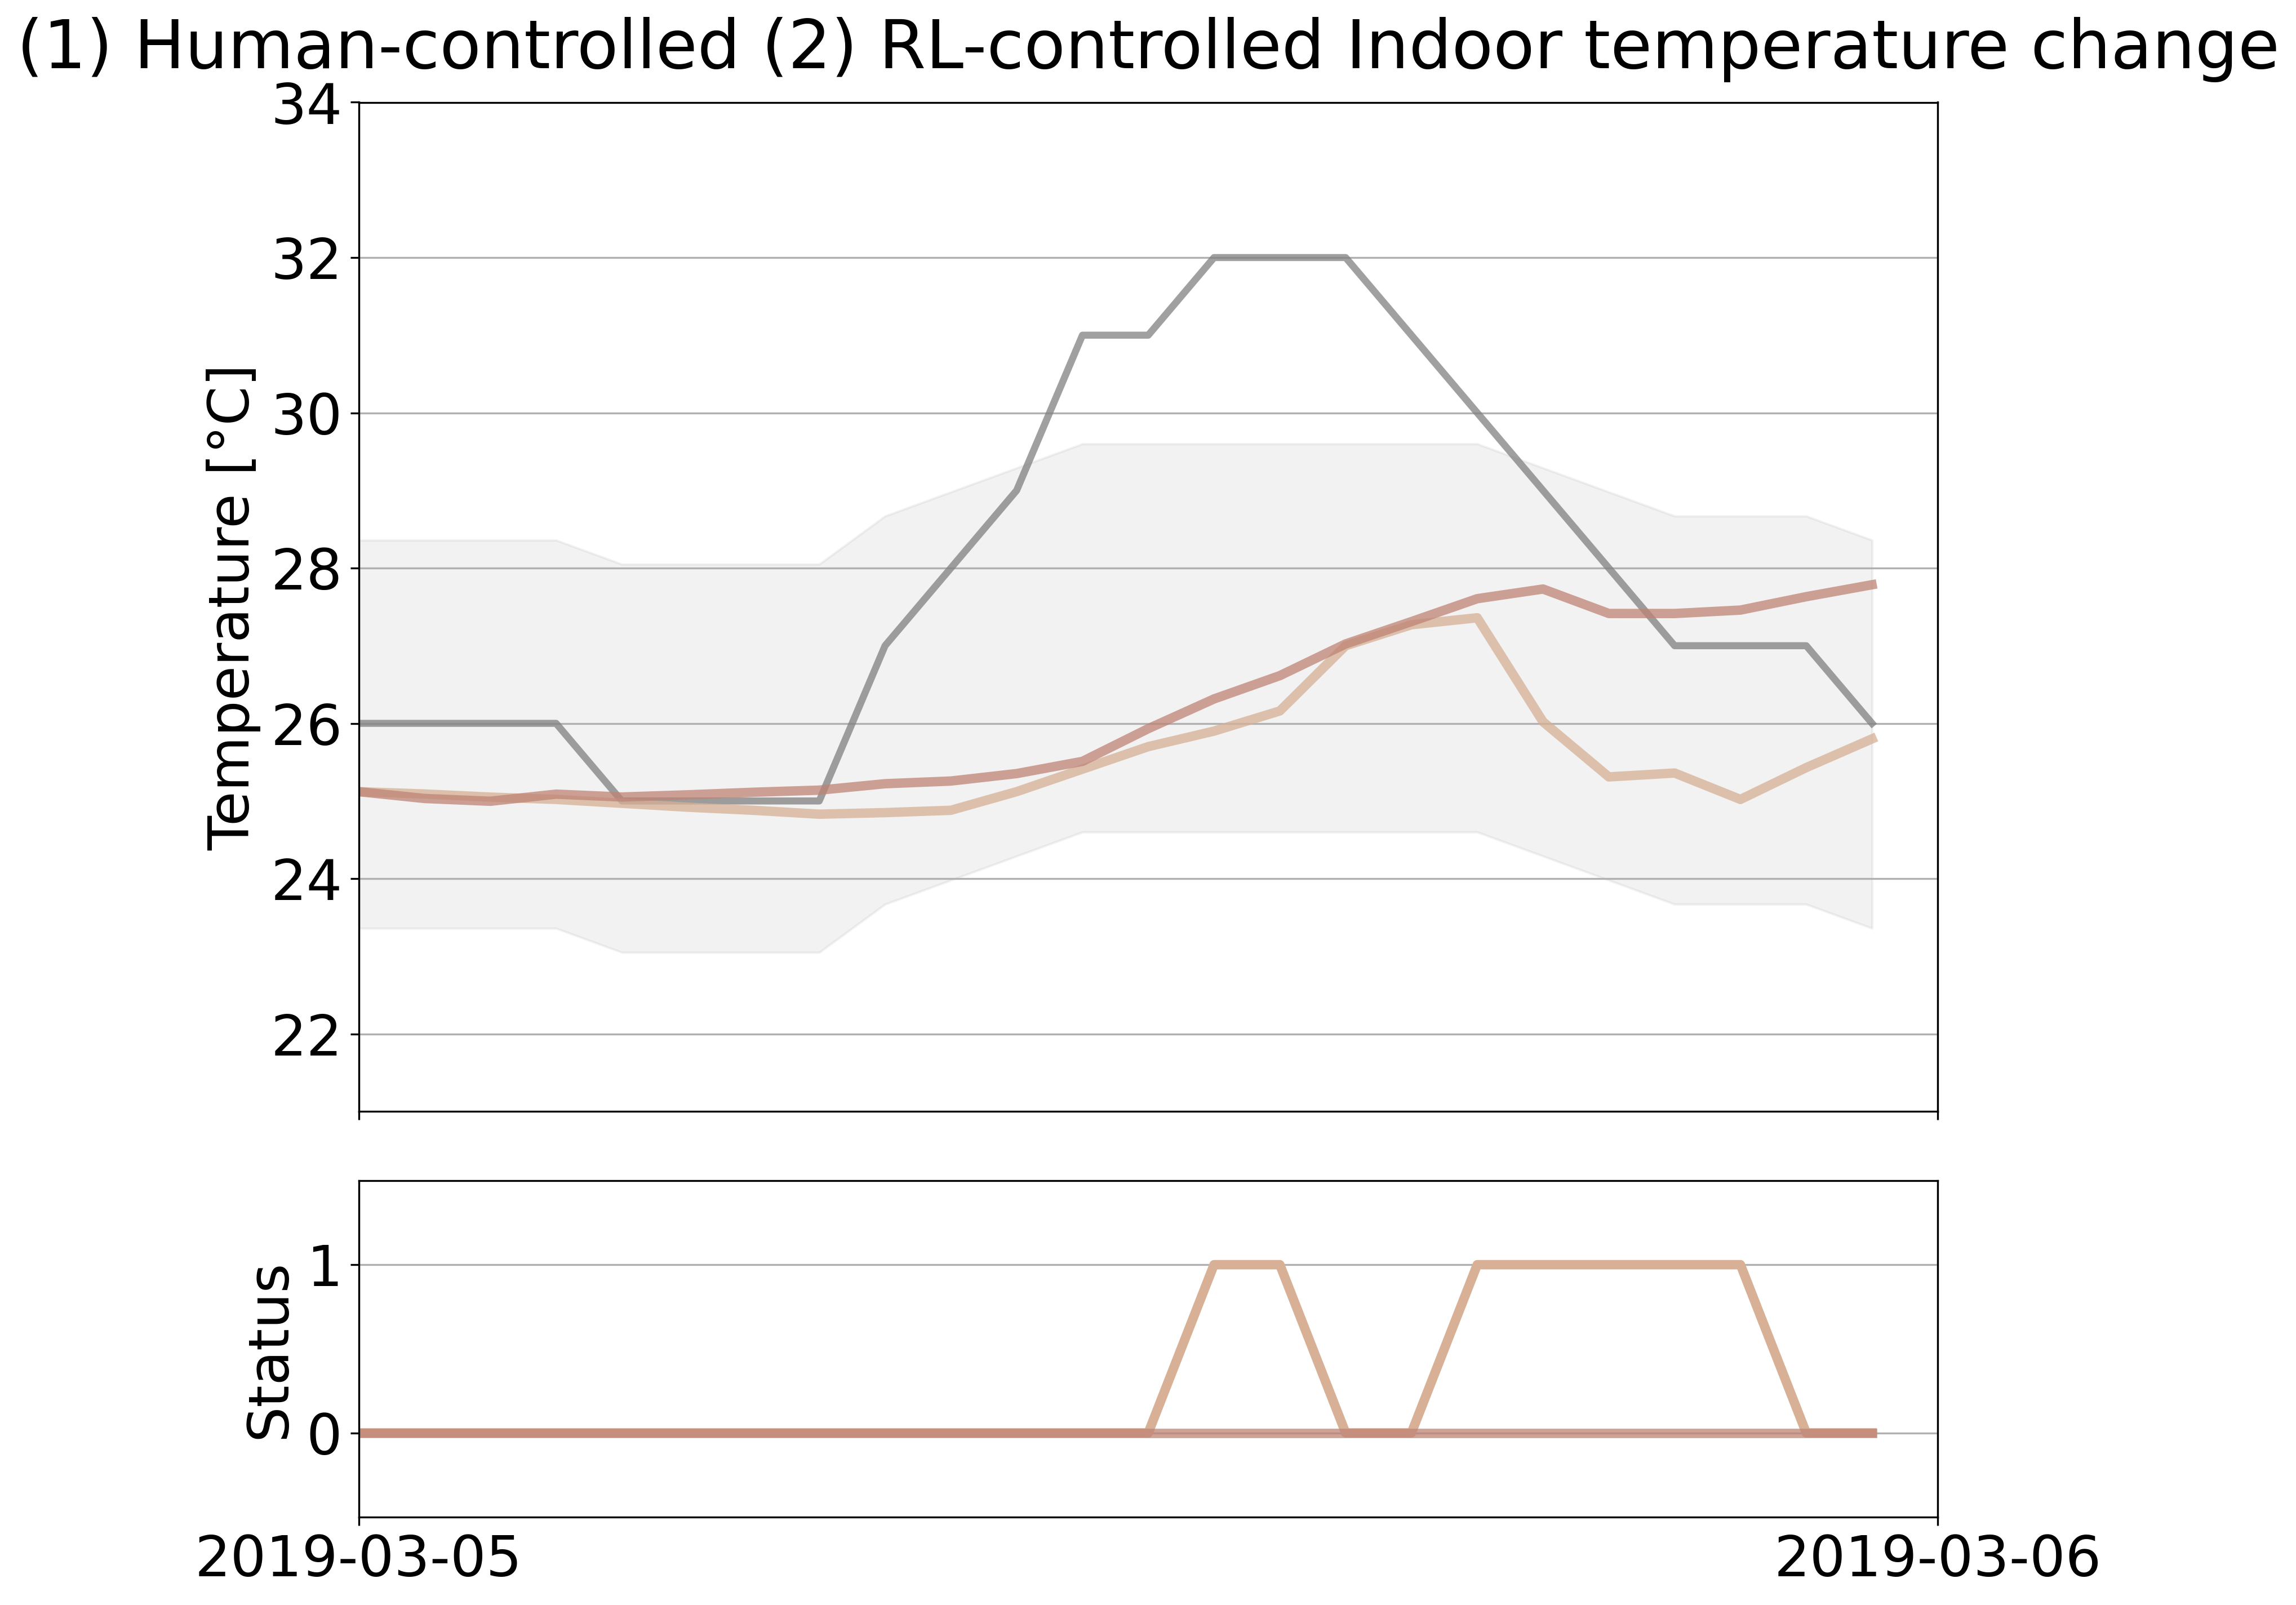

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc, dates
from datetime import datetime
rc('font', family='Times New Roman', size=24)

standard = 'ASHRAE'
coordinates_dict = {'ASHRAE': [[17.4, 18.4, 23.4, 24.4], [23.6, 24.6, 29.6, 30.6], [10, 30]]}
L11, L12, U12, U11 = coordinates_dict[standard][0]
L21, L22, U22, U21 = coordinates_dict[standard][1]
T1, T2 = coordinates_dict[standard][2]

data_or_ = pd.read_csv(xgb_file)
data_or = data_or_[:24]
OutT = data_or['Outdoor_Temp']
data_or['Date_Time'] = pd.to_datetime(data_or['Date_Time'])
data_or = data_or.sort_values(by='Date_Time')
data_or.set_index('Date_Time', inplace=True)
UP = []
LO = []
for temp in OutT:
    if temp <= T1:
        L1, L2, U2, U1 = L11, L12, U12, U11
    elif temp >= T2:
        L1, L2, U2, U1 = L21, L22, U22, U21
    else:
        increase = (temp - T1) * (L21 - L11) / (T2 - T1)
        L1, L2, U2, U1 = L11 + increase, L12 + increase, U12 + increase, U11 + increase
    UP.append(U1-1)
    LO.append(L1+1)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), dpi=300, sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot Temperature Change Line Chart
# 绘制温度变化折线图
ax1.plot(data_or.index, data_or['Outdoor_Temp'], label='Outdoor_Temp', color='gray', alpha=0.75, linewidth=3)
ax1.plot(data_or.index, data_or['Indoor_Temp'], linestyle='-', linewidth=4, label='(2) Human-controlled', color='#d7b095', alpha=0.75)
ax1.fill_between(data_or.index, LO, UP, color='grey', alpha=0.1, label='Comfort Zone', interpolate=True)
ax1.plot(data_or.index, next_in_temp_list, linestyle='-', linewidth=4, label='RL-controlled', color='#bf8375', alpha=0.75)

date_format = dates.DateFormatter('%Y-%m-%d')
ax1.xaxis.set_major_formatter(date_format)
ax1.xaxis.set_major_locator(dates.DayLocator(interval=1))
ax1.tick_params(axis='x', rotation=0)
ax1.set_title('(1) Human-controlled (2) RL-controlled Indoor temperature change',y=1.02)
ax1.set_ylabel('Temperature [°C]')
ax1.grid(True)
ax1.set_ylim(21, 34)
ax1.set_xlim(datetime(2019, 3, 5), datetime(2019, 3, 6))

# Plot Air Conditioning Status Line Chart
# 绘制空调状态折线图
ax2.plot(data_or.index, data_or['AC_Status'], linestyle='-', linewidth=4, label='AC_status', color='#d7b095', alpha=1)
ax2.plot(data_or.index, AC_Status_List, linestyle='-', linewidth=4, label='AC_Status_List', color='#bf8375', alpha=0.75)
ax2.xaxis.set_major_formatter(date_format)
ax2.xaxis.set_major_locator(dates.DayLocator(interval=1))
ax2.tick_params(axis='x', rotation=0)
ax2.set_ylabel('Status')
ax2.grid(True)
ax2.set_ylim(-0.5, 1.5)
ax2.set_xlim(datetime(2019, 3, 5), datetime(2019, 3, 6))

plt.tight_layout()
plt.show()

In [23]:
# S9 Visual HVAC Simulation (animated)
# Mô phỏng trực quan trạng thái môi trường theo thời gian từ kết quả đã chạy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",  # tránh warning thiếu Times New Roman
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    }
)

if "data_or" not in globals():
    data_or_ = pd.read_csv(xgb_file)
    data_or = data_or_[:24].copy()
    data_or["Date_Time"] = pd.to_datetime(data_or["Date_Time"])
    data_or = data_or.sort_values(by="Date_Time").set_index("Date_Time")

if "next_in_temp_list" not in globals() or "AC_Status_List" not in globals():
    raise RuntimeError(
        "Chưa có kết quả RL để trực quan hóa. Hãy chạy các cell huấn luyện/suy luận trước "
        "để tạo next_in_temp_list và AC_Status_List."
    )

n = min(len(data_or), len(next_in_temp_list), len(AC_Status_List))
plot_df = pd.DataFrame(
    {
        "time": data_or.index[:n],
        "outdoor_temp": data_or["Outdoor_Temp"].to_numpy()[:n],
        "human_indoor_temp": data_or["Indoor_Temp"].to_numpy()[:n],
        "rl_indoor_temp": np.asarray(next_in_temp_list[:n], dtype=float),
        "human_ac": data_or["AC_Status"].to_numpy()[:n],
        "rl_ac": np.asarray(AC_Status_List[:n], dtype=float),
        "window": data_or["Window_Status"].to_numpy()[:n] if "Window_Status" in data_or.columns else np.zeros(n),
        "rh": data_or["Humidity"].to_numpy()[:n] if "Humidity" in data_or.columns else np.full(n, 55.0),
        "hvac_power": data_or["Power_Consumption"].to_numpy()[:n] if "Power_Consumption" in data_or.columns else np.zeros(n),
    }
)

plot_df["rl_ac"] = (plot_df["rl_ac"] > 0.5).astype(float)
plot_df["human_ac"] = (plot_df["human_ac"] > 0.5).astype(float)
plot_df["window"] = (plot_df["window"] > 0.5).astype(float)

temp_min = float(np.nanmin(plot_df[["human_indoor_temp", "rl_indoor_temp", "outdoor_temp"]].to_numpy()))
temp_max = float(np.nanmax(plot_df[["human_indoor_temp", "rl_indoor_temp", "outdoor_temp"]].to_numpy()))

# Tăng khoảng cách giữa 2 panel để chữ không đè nhau
fig = plt.figure(figsize=(14, 6), dpi=120, constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.35], wspace=0.20)

ax_room = fig.add_subplot(gs[0, 0])
ax_ts = fig.add_subplot(gs[0, 1])

# --- Left panel ---
ax_room.set_title("Room State", pad=10)
ax_room.set_xlim(0, 10)
ax_room.set_ylim(0, 10)
ax_room.axis("off")

room_rect = Rectangle((1.1, 1.2), 7.7, 7.2, linewidth=1.8, edgecolor="#1f1f1f", facecolor="#f2f2f2")
ax_room.add_patch(room_rect)

ac_rect = Rectangle((1.7, 7.7), 1.8, 0.55, linewidth=1.0, edgecolor="#0b5394", facecolor="#9fc5e8")
ax_room.add_patch(ac_rect)
ax_room.text(2.6, 8.45, "AC", ha="center", va="bottom", fontsize=10, color="#0b5394")

window_rect = Rectangle((8.35, 4.7), 0.30, 2.15, linewidth=1.0, edgecolor="#134f5c", facecolor="#cfe2f3")
ax_room.add_patch(window_rect)
window_state_text = ax_room.text(8.92, 5.8, "Window", ha="left", va="center", fontsize=9)

sensor = Circle((4.95, 4.5), 0.13, color="#555555")
ax_room.add_patch(sensor)

status_text = ax_room.text(1.1, 9.25, "", fontsize=9, va="center", ha="left")
info_text = ax_room.text(1.1, 0.55, "", fontsize=9, va="center", ha="left")

# --- Right panel ---
ax_ts.set_title("Indoor Temperature Trajectory", pad=10)
ax_ts.set_xlabel("Timestep")
ax_ts.set_ylabel("Temperature [°C]", labelpad=8)
ax_ts.grid(alpha=0.25)

x = np.arange(n)
out_line, = ax_ts.plot([], [], label="Outdoor", color="#7a7a7a", linewidth=1.8)
human_line, = ax_ts.plot([], [], label="Human", color="#d7b095", linewidth=2.2)
rl_line, = ax_ts.plot([], [], label="RL", color="#bf8375", linewidth=2.2)

ax_ts.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#dddddd")
ax_ts.set_xlim(0, max(1, n - 1))
ax_ts.set_ylim(temp_min - 1.5, temp_max + 1.5)

vline = ax_ts.axvline(0, color="#444444", linestyle="--", alpha=0.65, linewidth=1.2)


def _temp_to_color(temp):
    if temp_max <= temp_min:
        return plt.cm.coolwarm(0.5)
    alpha = (temp - temp_min) / (temp_max - temp_min)
    return plt.cm.coolwarm(float(np.clip(alpha, 0.0, 1.0)))


def init():
    out_line.set_data([], [])
    human_line.set_data([], [])
    rl_line.set_data([], [])
    vline.set_xdata([0, 0])
    status_text.set_text("")
    info_text.set_text("")
    return out_line, human_line, rl_line, vline, status_text, info_text


def update(frame):
    indoor_t = float(plot_df.loc[frame, "rl_indoor_temp"])
    outdoor_t = float(plot_df.loc[frame, "outdoor_temp"])
    rh = float(plot_df.loc[frame, "rh"])
    hvac_power = float(plot_df.loc[frame, "hvac_power"])
    ac_on = int(plot_df.loc[frame, "rl_ac"])
    window_open = int(plot_df.loc[frame, "window"])

    room_rect.set_facecolor(_temp_to_color(indoor_t))
    ac_rect.set_facecolor("#6fa8dc" if ac_on else "#d9d9d9")

    window_rect.set_facecolor("#9fc5e8" if window_open else "#eeeeee")
    window_state_text.set_text("Window: OPEN" if window_open else "Window: CLOSE")

    status_text.set_text(f"Step {frame + 1}/{n} | AC: {'ON' if ac_on else 'OFF'} | Window: {'OPEN' if window_open else 'CLOSE'}")
    info_text.set_text(f"Indoor: {indoor_t:.2f}°C | Outdoor: {outdoor_t:.2f}°C | RH: {rh:.1f}% | Power: {hvac_power:.1f}")

    out_line.set_data(x[: frame + 1], plot_df["outdoor_temp"].to_numpy()[: frame + 1])
    human_line.set_data(x[: frame + 1], plot_df["human_indoor_temp"].to_numpy()[: frame + 1])
    rl_line.set_data(x[: frame + 1], plot_df["rl_indoor_temp"].to_numpy()[: frame + 1])
    vline.set_xdata([frame, frame])

    return out_line, human_line, rl_line, vline, room_rect, ac_rect, window_rect, window_state_text, status_text, info_text


anim = FuncAnimation(fig, update, frames=n, init_func=init, interval=450, blit=False, repeat=True)
plt.close(fig)

display(HTML(anim.to_jshtml()))

In [ ]:
# (Optional) Save animation to GIF for report
# Cài thêm nếu thiếu: pip install pillow

# Uncomment to export
# from matplotlib.animation import PillowWriter
# anim.save("hvac_visual_simulation.gif", writer=PillowWriter(fps=2))
# print("Saved: hvac_visual_simulation.gif")